In [1]:
%pip install tld
%pip install xgboost
%pip install LGBMClassifier
%pip install lightgbm
import pandas as pd
import itertools
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from lightgbm import LGBMClassifier
import os
import seaborn as sns
from wordcloud import WordCloud



Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement LGBMClassifier (from versions: none)
ERROR: No matching distribution found for LGBMClassifier


Note: you may need to restart the kernel to use updated packages.


In [2]:
df=pd.read_csv('./malicious_phish.csv.csv')
print(df.shape)
df.head()

(651191, 2)


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [3]:
df.type.value_counts()

type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

plot wordcloud

In [4]:
df_phish= df[df.type=="phishing"]
df_malware=df[df.type=="malware"]
df_deface=df[df.type=="defacement"]
df_benign=df[df.type=="benign"]

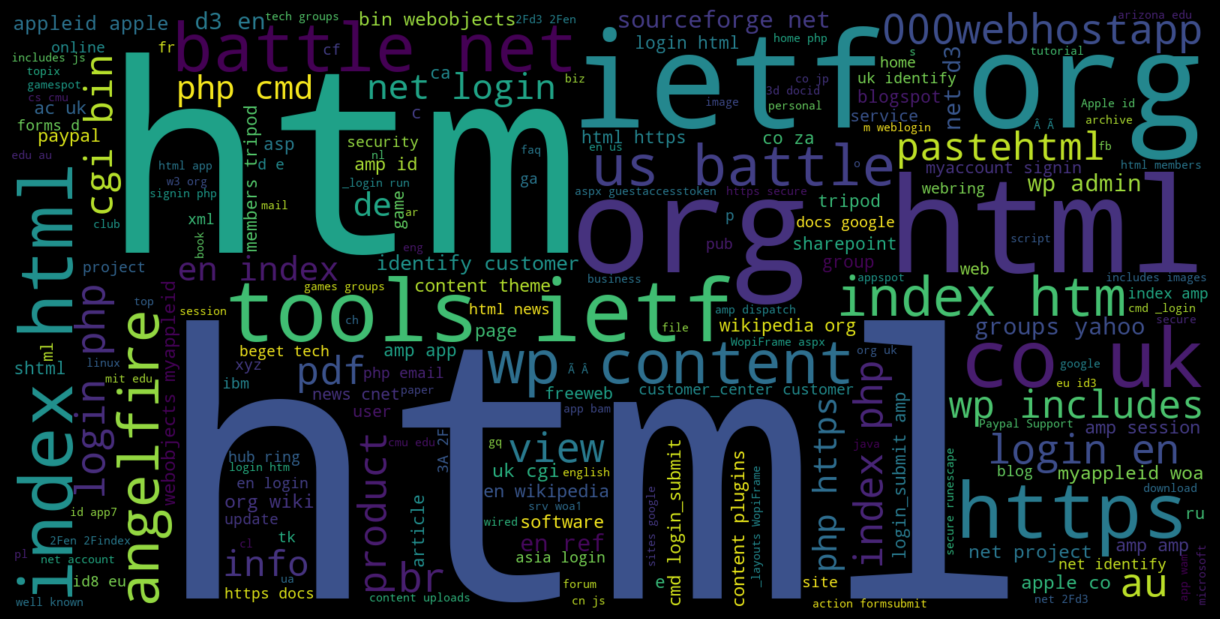

In [5]:
phish_url=" ".join (i for i in df_phish.url)
wordcloud= WordCloud(width=1600,height=800,colormap="viridis").generate(phish_url)
plt.figure(figsize=(12,10),facecolor="k")
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()



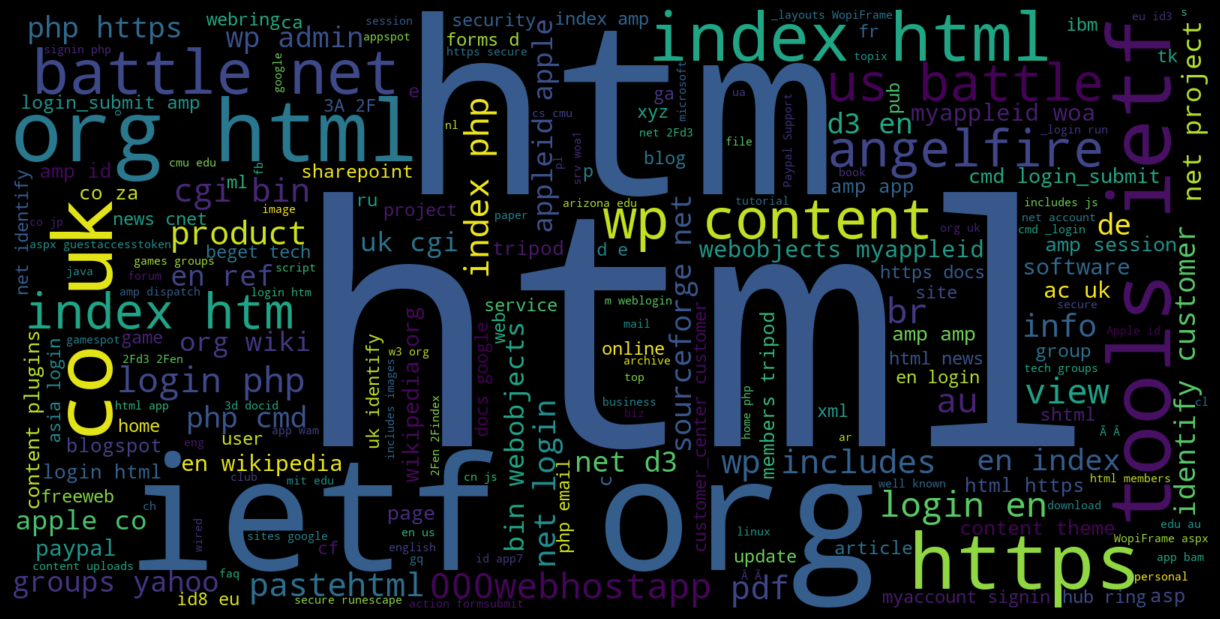

In [6]:
malware_url=" ".join (i for i in df_malware.url)
wordcloud= WordCloud(width=1600,height=800,colormap="viridis").generate(phish_url)
plt.figure(figsize=(12,10),facecolor="k")
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


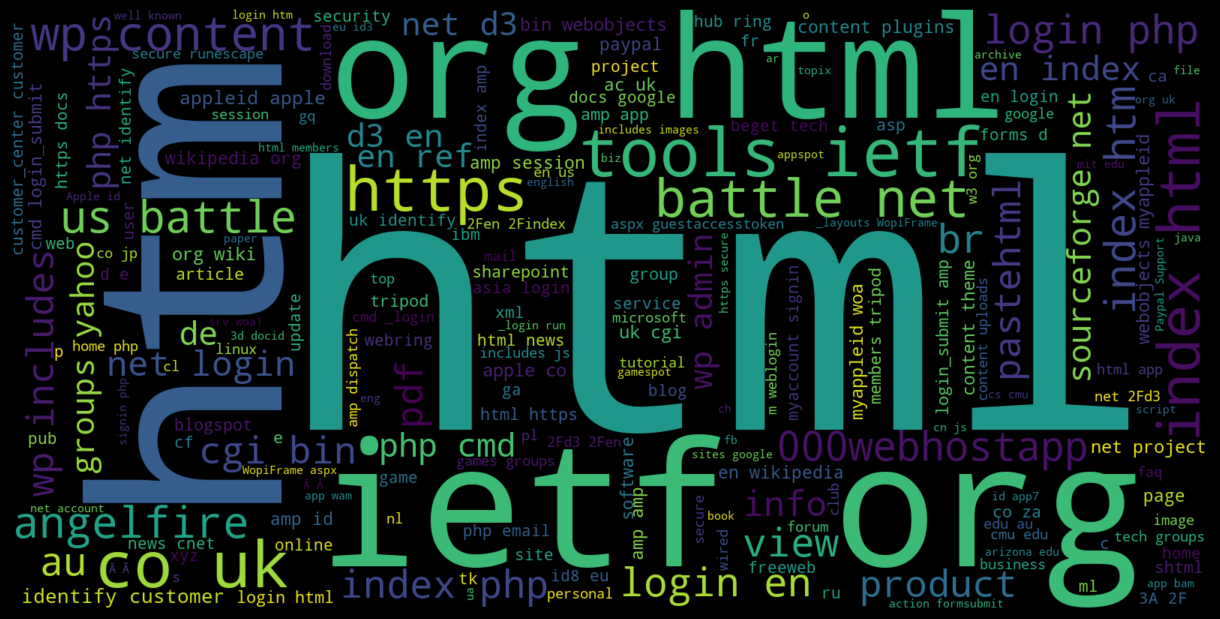

In [7]:
deface_url=" ".join (i for i in df_deface.url)
wordcloud= WordCloud(width=1600,height=800,colormap="viridis").generate(phish_url)
plt.figure(figsize=(12,10),facecolor="k")
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

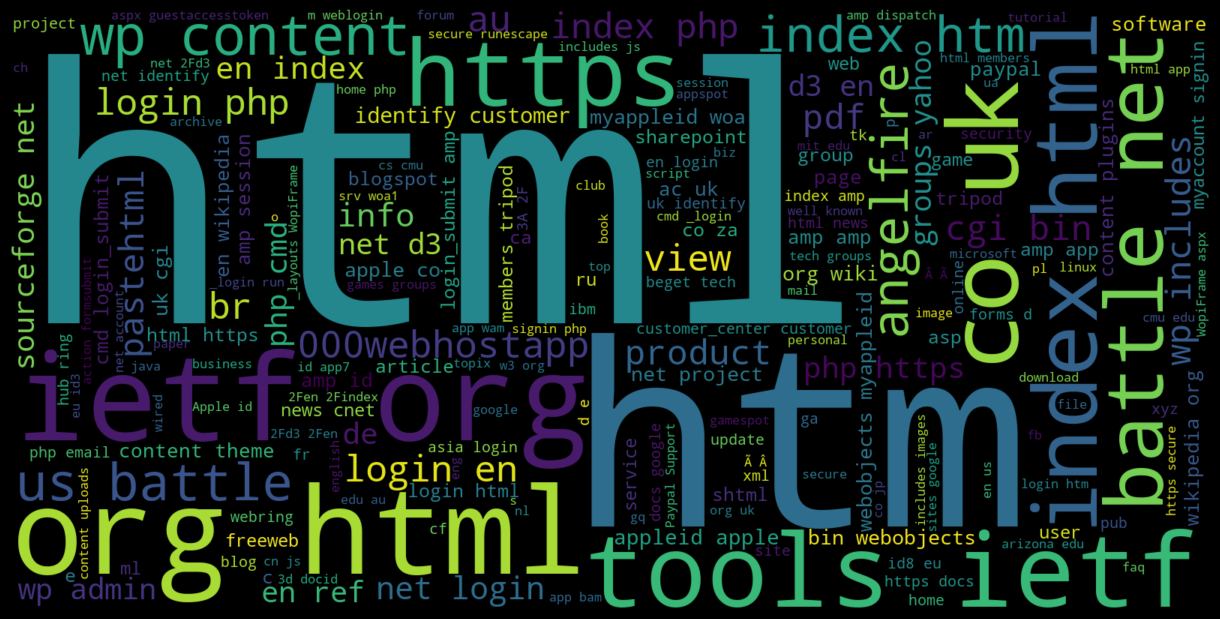

In [8]:
benign_url=" ".join (i for i in df_benign.url)
wordcloud= WordCloud(width=1600,height=800,colormap="viridis").generate(phish_url)
plt.figure(figsize=(12,10),facecolor="k")
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

feature engineering

In [9]:
import re
#Use of IP or not in domain
def having_ip_address(url):
    match = re.search(
        '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\/)|'  # IPv4
        '((0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\/)' # IPv4 in hexadecimal
        '(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url)  # Ipv6
    if match:
        # print match.group()
        return 1
    else:
        # print 'No matching pattern found'
        return 0
df['use_of_ip'] = df['url'].apply(lambda i: having_ip_address(i))

from urllib.parse import urlparse

def abnormal_url(url):
    hostname = urlparse(url).hostname
    hostname = str(hostname)
    match = re.search(hostname, url)
    if match:
        # print match.group()
        return 1
    else:
        # print 'No matching pattern found'
        return 0


df['abnormal_url'] = df['url'].apply(lambda i: abnormal_url(i))

#pip install googlesearch-python

from googlesearch import search

def google_index(url):
    site = search(url, 5)
    return 1 if site else 0
df['google_index'] = df['url'].apply(lambda i: google_index(i))

def count_dot(url):
    count_dot = url.count('.')
    return count_dot

df['count.'] = df['url'].apply(lambda i: count_dot(i))

def count_www(url):
    url.count('www')
    return url.count('www')

df['count-www'] = df['url'].apply(lambda i: count_www(i))

def count_atrate(url):

    return url.count('@')

df['count@'] = df['url'].apply(lambda i: count_atrate(i))


def no_of_dir(url):
    urldir = urlparse(url).path
    return urldir.count('/')

df['count_dir'] = df['url'].apply(lambda i: no_of_dir(i))

def no_of_embed(url):
    urldir = urlparse(url).path
    return urldir.count('//')

df['count_embed_domian'] = df['url'].apply(lambda i: no_of_embed(i))


def shortening_service(url):
    match = re.search('bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
                      'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
                      'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
                      'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
                      'db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
                      'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
                      'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
                      'tr\.im|link\.zip\.net',
                      url)
    if match:
        return 1
    else:
        return 0

df['short_url'] = df['url'].apply(lambda i: shortening_service(i))

def count_https(url):
    return url.count('https')

df['count-https'] = df['url'].apply(lambda i : count_https(i))

def count_http(url):
    return url.count('http')

df['count-http'] = df['url'].apply(lambda i : count_http(i))

def count_per(url):
    return url.count('%')

df['count%'] = df['url'].apply(lambda i : count_per(i))

def count_ques(url):
    return url.count('?')

df['count?'] = df['url'].apply(lambda i: count_ques(i))

def count_hyphen(url):
    return url.count('-')

df['count-'] = df['url'].apply(lambda i: count_hyphen(i))

def count_equal(url):
    return url.count('=')

df['count='] = df['url'].apply(lambda i: count_equal(i))

def url_length(url):
    return len(str(url))


#Length of URL
df['url_length'] = df['url'].apply(lambda i: url_length(i))
#Hostname Length

def hostname_length(url):
    return len(urlparse(url).netloc)

df['hostname_length'] = df['url'].apply(lambda i: hostname_length(i))

df.head()

def suspicious_words(url):
    match = re.search('PayPal|login|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr',
                      url)
    if match:
        return 1
    else:
        return 0
df['sus_url'] = df['url'].apply(lambda i: suspicious_words(i))


def digit_count(url):
    digits = 0
    for i in url:
        if i.isnumeric():
            digits = digits + 1
    return digits


df['count-digits']= df['url'].apply(lambda i: digit_count(i))


def letter_count(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters = letters + 1
    return letters

df['count-letters']= df['url'].apply(lambda i: letter_count(i))

 #pip install tld

from urllib.parse import urlparse
from tld import get_tld
import os.path

#First Directory Length
def fd_length(url):
    urlpath= urlparse(url).path
    try:
        return len(urlpath.split('/')[1])
    except:
        return 0

df['fd_length'] = df['url'].apply(lambda i: fd_length(i))

#Length of Top Level Domain
df['tld'] = df['url'].apply(lambda i: get_tld(i,fail_silently=True))


def tld_length(tld):
    try:
        return len(tld)
    except:
        return -1

df['tld_length'] = df['tld'].apply(lambda i: tld_length(i))

In [10]:
%pip install googlesearch_paython

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement googlesearch_paython (from versions: none)
ERROR: No matching distribution found for googlesearch_paython


In [11]:
from googlesearch import search

In [12]:
def google_index(url):
  site= search(url,5)
  return 1 if site else 0
  df['googel_index']=df['url'].applay(lambda i: google_index(i))


In [13]:
def count_dot(url):
    count_dot = url.count('.')
    return count_dot

df['count.'] = df['url'].apply(lambda i: count_dot(i))
df.head()


,url,type,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,count_embed_domian,...,count-,count=,url_length,hostname_length,sus_url,count-digits,count-letters,fd_length,tld,tld_length
0,br-icloud.com.br,phishing,0,0,1,2,0,0,0,0,...,1,0,16,0,0,0,13,0,None,-1
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2,0,0,2,0,...,0,0,35,0,0,1,29,5,None,-1
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2,0,0,3,0,...,0,0,31,0,0,1,25,7,None,-1
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3,1,0,1,0,...,1,4,88,21,0,7,63,9,be,2
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2,0,0,1,0,...,1,3,235,23,0,22,199,9,net,3


In [14]:
import re
from urllib.parse import urlparse

def count_www(url):
    return url.count('www')

df['count_www'] = df['url'].apply(lambda i: count_www(i))


def count_atrate(url):
    return url.count('@')

df['count@'] = df['url'].apply(lambda i: count_atrate(i))


def no_of_dir(url):
    urldir = urlparse(url).path
    return urldir.count('/')

df['count_dir'] = df['url'].apply(lambda i: no_of_dir(i))

def no_of_embed(url):
    urldir = urlparse(url).path
    return urldir.count('//')

df['count_embed_domian'] = df['url'].apply(lambda i: no_of_embed(i))

def shortening_service(url):
    match = re.search(
        'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
        'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
        'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
        'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|lnkd\.in|'
        'db\.tt|qr\.ae|adf\.ly|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|ity\.im|q\.gs|po\.st|bc\.vc|'
        'twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|prettylinkpro\.com|'
        'scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|link\.zip\.net', url)

    if match:
        return 1
    else:
        return 0

df['short_url'] = df['url'].apply(lambda i: shortening_service(i))



In [15]:
df['count-https'] = df['url'].apply(lambda i: count_https(i))

def count_http(url):
    return url.count('http')

df['count-http'] = df['url'].apply(lambda i: count_http(i))


In [16]:
def count_per(url):
    return url.count('%')

df['count%'] = df['url'].apply(lambda i: count_per(i))

def count_ques(url):
    return url.count('?')

df['count?'] = df['url'].apply(lambda i: count_ques(i))

def count_hyphen(url):
    return url.count('-')

df['count-'] = df['url'].apply(lambda i: count_hyphen(i))

def count_equal(url):
    return url.count('=')

df['count='] = df['url'].apply(lambda i: count_equal(i))

def url_length(url):
    return len(str(url))

    df['url_length'] = df['url'].apply(lambda i: url_length(i))

def hostname_length(url):
    return len(urlparse(url).netloc)

df['hostname_length'] = df['url'].apply(lambda i: hostname_length(i))

def suspicious_words(url):
    match = re.search('PayPal|login|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr', url)
    return 1 if match else 0

df['sus_url'] = df['url'].apply(lambda i: suspicious_words(i))

def digit_count(url):
    return sum(1 for i in url if i.isdigit())

df['count-digits'] = df['url'].apply(lambda i: digit_count(i))

def letter_count(url):
    return sum(1 for i in url if i.isalpha())

df['count-letters'] = df['url'].apply(lambda i: letter_count(i))

def fd_length(url):
    urlpath = urlparse(url).path
    try:
        return len(urlpath.split('/')[1])
    except:
        return 0

df['fd_length'] = df['url'].apply(lambda i: fd_length(i))

df['tld'] = df['url'].apply(lambda i: get_tld(i, fail_silently=True))

def tld_length(tld):
    try:
        return len(tld)
    except:
        return -1

df['tld_length'] = df['tld'].apply(lambda i: tld_length(i))
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,count_embed_domian,...,count=,url_length,hostname_length,sus_url,count-digits,count-letters,fd_length,tld,tld_length,count_www
0,br-icloud.com.br,phishing,0,0,1,2,0,0,0,0,...,0,16,0,0,0,13,0,None,-1,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2,0,0,2,0,...,0,35,0,0,1,29,5,None,-1,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2,0,0,3,0,...,0,31,0,0,1,25,7,None,-1,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3,1,0,1,0,...,4,88,21,0,7,63,9,be,2,1
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2,0,0,1,0,...,3,235,23,0,22,199,9,net,3,0


In [17]:
from urllib.parse import urlparse
from tld import get_tld
import os


def fd_length(url):
    urlpath = urlparse(url).path
    try:
        return len(urlpath.split('/'))
    except:
        return 0

df['fd_length'] = df['url'].apply(lambda i: fd_length(i))


df['tld'] = df['url'].apply(lambda i: get_tld(i, fail_silently=True))


def tld_length(tld):
    try:
        return len(tld)
    except:
        return -1

df['tld_length'] = df['tld'].apply(lambda i: tld_length(i))


In [18]:
df =df.drop("tld", axis=1)


In [19]:
df.columns

Index(['url', 'type', 'use_of_ip', 'abnormal_url', 'google_index', 'count.',
       'count-www', 'count@', 'count_dir', 'count_embed_domian', 'short_url',
       'count-https', 'count-http', 'count%', 'count?', 'count-', 'count=',
       'url_length', 'hostname_length', 'sus_url', 'count-digits',
       'count-letters', 'fd_length', 'tld_length', 'count_www'],
      dtype='object')

In [20]:
df['type'].value_counts()

type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

1-Dstripution of use_of_ip

<Axes: xlabel='type', ylabel='count'>

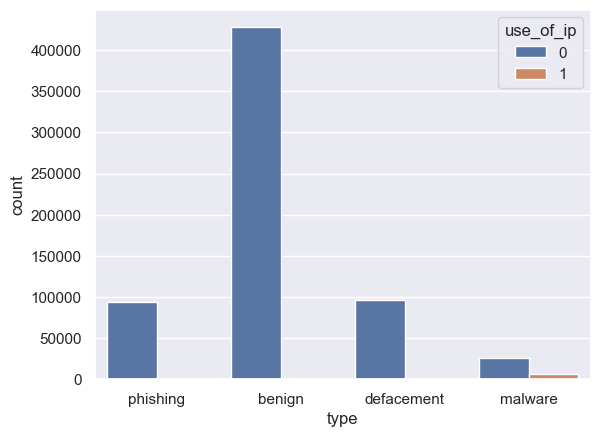

In [21]:
import seaborn as sns
sns.set(style="darkgrid")
sns.countplot(x="type",data=df,hue="use_of_ip")

2-Distripution of abnormal url

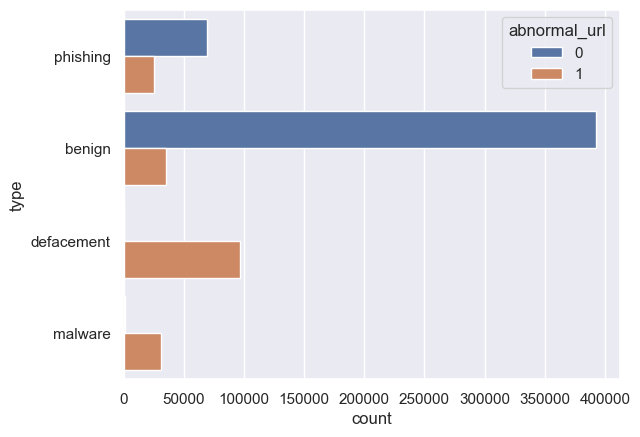

In [22]:
sns.set(style="darkgrid")
ax = sns.countplot(y="type",data=df,hue="abnormal_url")

3-Distripution of Google index

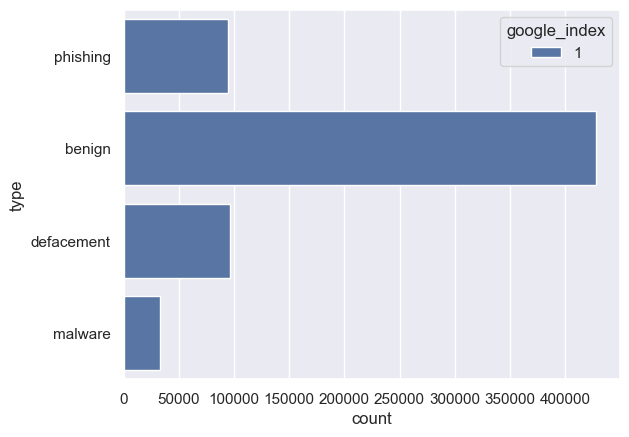

In [23]:
sns.set(style="darkgrid")
ax= sns.countplot(y="type",data=df,hue="google_index")

4-Distribution of shorl URL

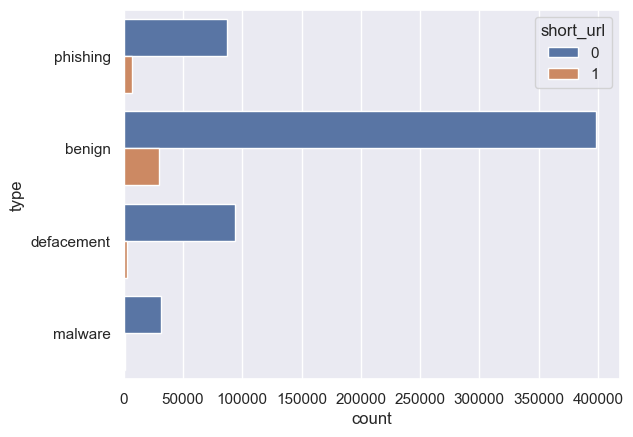

In [24]:
sns.set(style="darkgrid")
ax= sns.countplot(y="type",data=df,hue="short_url")

5-Distribution of suspicious URL

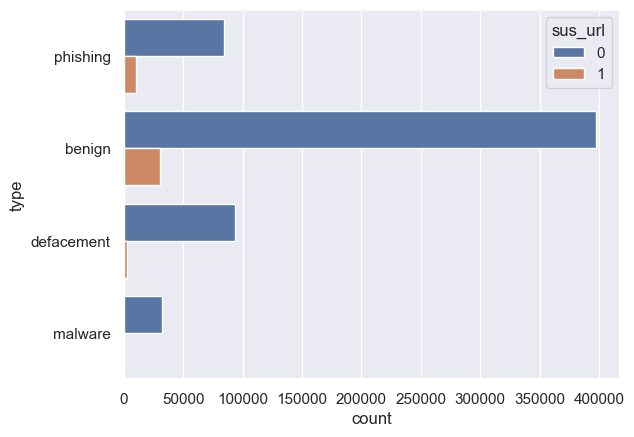

In [25]:
sns.set(style="darkgrid")
ax= sns.countplot(y="type",data=df,hue="sus_url")

6-Distripution of count of [.] dot

c:\Users\TW\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


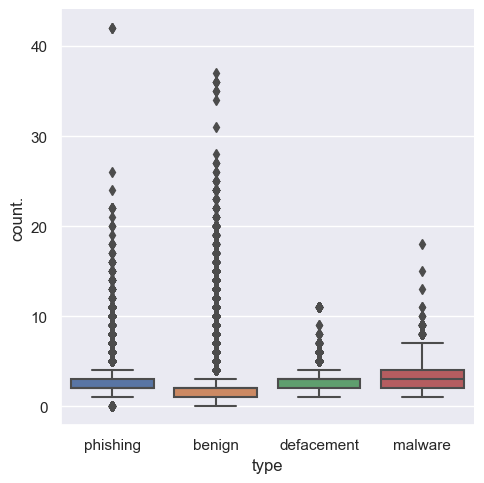

In [26]:
sns.set(style="darkgrid")
ax=sns.catplot(x="type",y="count.",kind="box",data=df)

7-Distripution of count_www

c:\Users\TW\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


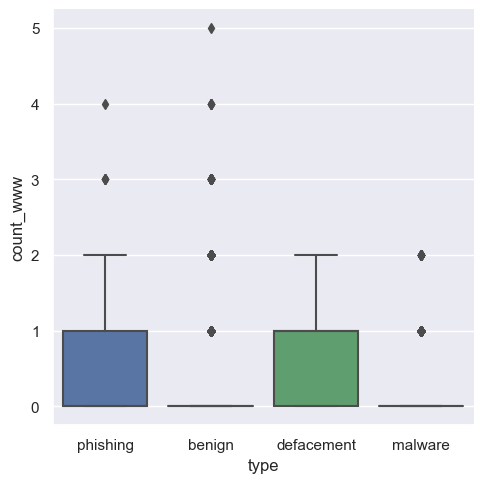

In [27]:
sns.set(style="darkgrid")
ax= sns.catplot(x="type",y="count_www",kind="box",data=df)

8-Distripution of count@

c:\Users\TW\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


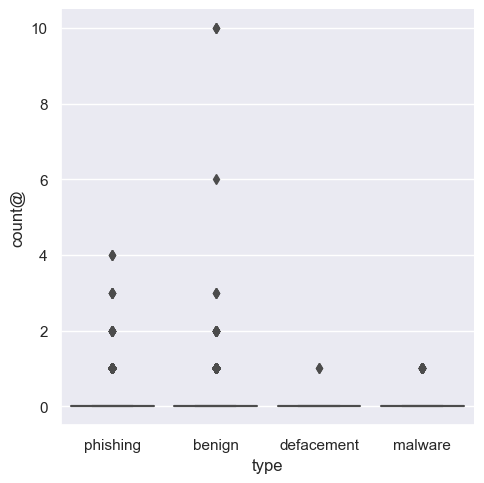

In [28]:
sns.set(style="darkgrid")
ax=sns.catplot(x="type",y="count@",kind="box",data=df)

9-Distripution of count_dir

c:\Users\TW\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


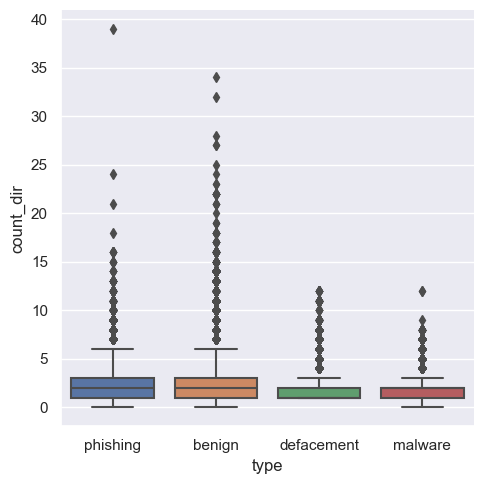

In [29]:
sns.set(style="darkgrid")
ax=sns.catplot(x="type",y="count_dir",kind="box",data=df)

10-Distribution of hostname length

c:\Users\TW\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


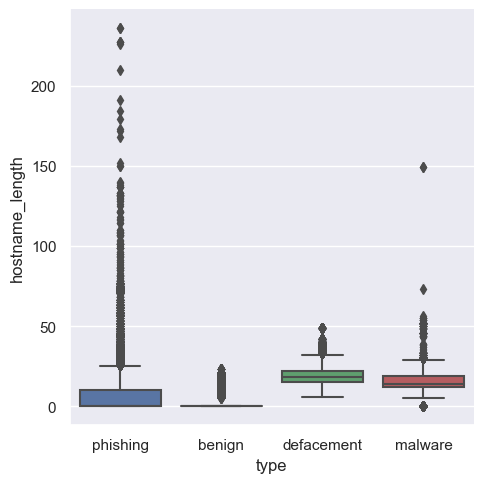

In [30]:
sns.set(style="darkgrid")
ax= sns.catplot(x="type",y="hostname_length",kind="box",data=df)

11-Distribution of first directory length

c:\Users\TW\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


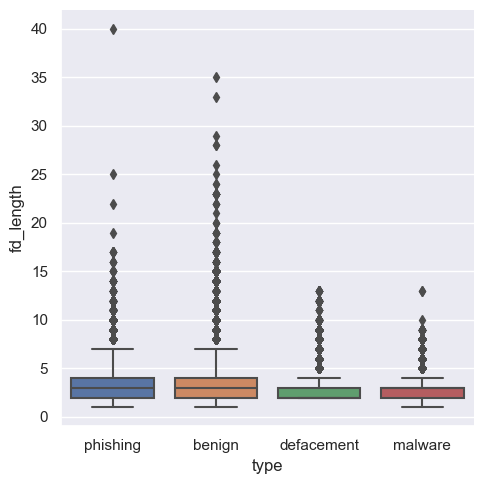

In [31]:
sns.set(style="darkgrid")
ax= sns.catplot(x="type",y="fd_length",kind="box",data=df)

12-Distripution of top_level domain lenght

c:\Users\TW\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


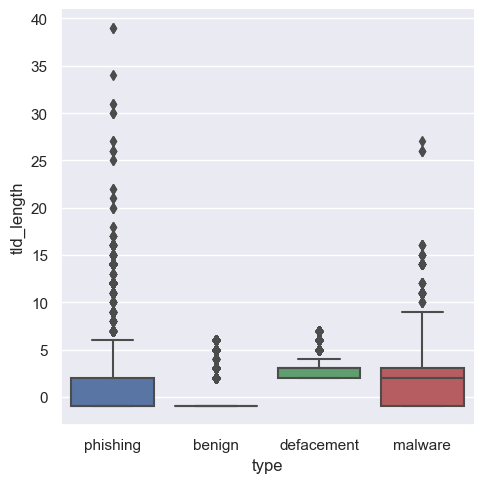

In [32]:
sns.set(style="darkgrid")
ax= sns.catplot(x="type",y="tld_length",kind="box",data=df)

Target Encoding


In [33]:
from sklearn.preprocessing import LabelEncoder
lb_make=LabelEncoder()
df['type_code'] = lb_make.fit_transform(df["type"])
df['type_code'].value_counts()

type_code
0    428103
1     96457
3     94111
2     32520
Name: count, dtype: int64

In [34]:
print(df.columns.tolist())


['url', 'type', 'use_of_ip', 'abnormal_url', 'google_index', 'count.', 'count-www', 'count@', 'count_dir', 'count_embed_domian', 'short_url', 'count-https', 'count-http', 'count%', 'count?', 'count-', 'count=', 'url_length', 'hostname_length', 'sus_url', 'count-digits', 'count-letters', 'fd_length', 'tld_length', 'count_www', 'type_code']


In [35]:
# predictor variables
# filtering out google_index as it only 1 value
x=df[['use_of_ip','abnormal_url','count.','count-www','count@','count_dir','count_embed_domian','short_url','count-https','count-http','count%','count?','count-','count=','url_length','hostname_length','sus_url','fd_length','tld_length','count-digits','count-letters']]
y = df['type']



In [36]:
x.head()

,use_of_ip,abnormal_url,count.,count-www,count@,count_dir,count_embed_domian,short_url,count-https,count-http,...,count?,count-,count=,url_length,hostname_length,sus_url,fd_length,tld_length,count-digits,count-letters
0,0,0,2,0,0,0,0,0,0,0,...,0,1,0,16,0,0,1,-1,0,13
1,0,0,2,0,0,2,0,0,0,0,...,0,0,0,35,0,0,3,-1,1,29
2,0,0,2,0,0,3,0,0,0,0,...,0,0,0,31,0,0,4,-1,1,25
3,0,1,3,1,0,1,0,0,0,1,...,1,1,4,88,21,0,2,2,7,63
4,0,1,2,0,0,1,0,0,0,1,...,1,1,3,235,23,0,2,3,22,199


In [37]:
x.columns

Index(['use_of_ip', 'abnormal_url', 'count.', 'count-www', 'count@',
       'count_dir', 'count_embed_domian', 'short_url', 'count-https',
       'count-http', 'count%', 'count?', 'count-', 'count=', 'url_length',
       'hostname_length', 'sus_url', 'fd_length', 'tld_length', 'count-digits',
       'count-letters'],
      dtype='object')

Train Test Split

In [38]:
# identify the nan values
valid_rows = y.notna()
x = x[valid_rows]
y = y[valid_rows]

# split data
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, shuffle=True, random_state=5)


model Building

1-Random forest classifier

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf=RandomForestClassifier(n_estimators=100,max_features='sqrt')
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
print(classification_report(y_test,y_pred_rf,target_names=['benign','defacemert','phishing','malware']))

score = accuracy_score(y_test, y_pred_rf)
print("accuracy : %.3f" % score)



              precision    recall  f1-score   support

      benign       0.97      0.99      0.98     85621
  defacemert       0.97      0.99      0.98     19292
    phishing       0.98      0.94      0.96      6504
     malware       0.90      0.83      0.87     18822

    accuracy                           0.96    130239
   macro avg       0.96      0.94      0.95    130239
weighted avg       0.96      0.96      0.96    130239

accuracy : 0.962


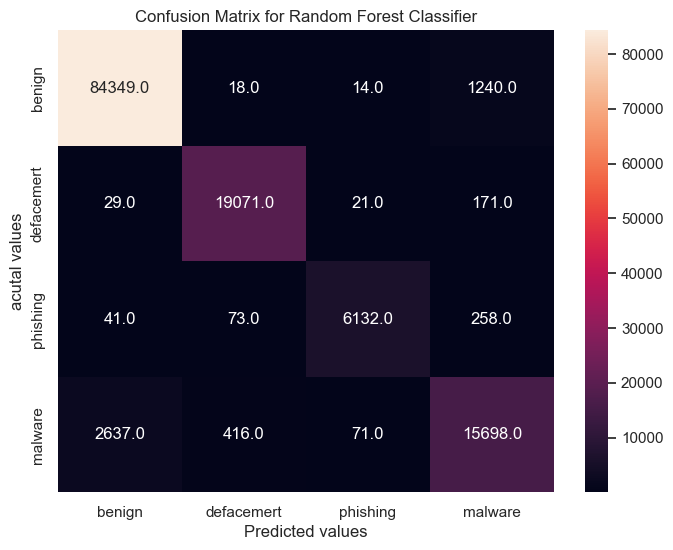

In [40]:
cm = confusion_matrix(y_test, y_pred_rf)
cm_df=pd.DataFrame(cm,index=['benign','defacemert','phishing','malware'],columns=['benign','defacemert','phishing','malware'])
plt.figure(figsize=(8,6))
sns.heatmap(cm_df,annot=True,fmt='.1f')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted values')
plt.ylabel('acutal values')
plt.show()

<Axes: >

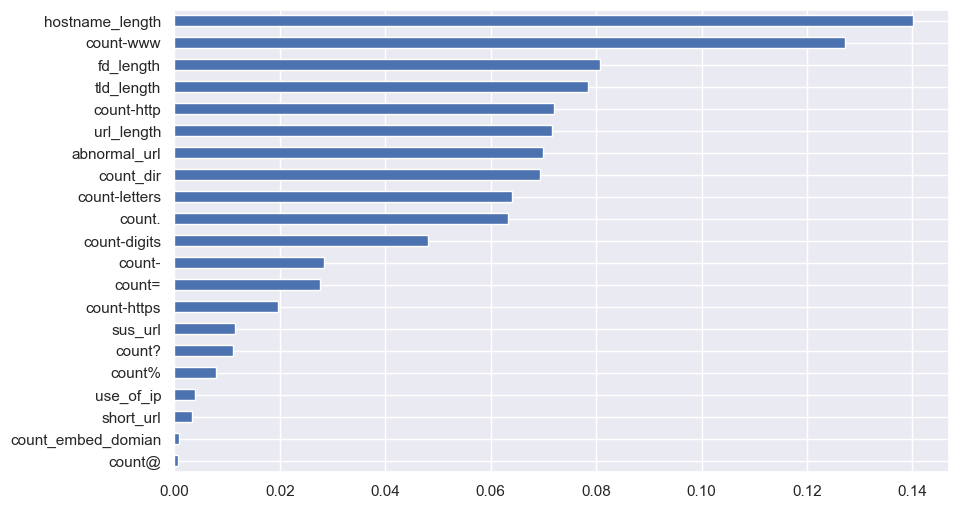

In [41]:
feat_importances= pd.Series(rf.feature_importances_,index=x.columns)
feat_importances.sort_values().plot(kind='barh',figsize=(10,6))

2-light GBM classifier

In [42]:
lgb = LGBMClassifier(objective='multiclass',boosting_type= 'gbdt',n_jobs = 5,
          verbose=-1, random_state=5,class_weight='balanced')
LGB_C = lgb.fit(x_train, y_train)
y_pred_lgb = LGB_C.predict(x_test)
print(classification_report(y_test,y_pred_lgb,target_names=['benign', 'defacement','phishing','malware']))
score = accuracy_score(y_test, y_pred_lgb)
print("accuracy:   %0.3f" % score)


              precision    recall  f1-score   support

      benign       0.98      0.95      0.96     85621
  defacement       0.95      0.98      0.96     19292
    phishing       0.90      0.93      0.92      6504
     malware       0.78      0.85      0.82     18822

    accuracy                           0.94    130239
   macro avg       0.90      0.93      0.92    130239
weighted avg       0.94      0.94      0.94    130239

accuracy:   0.940


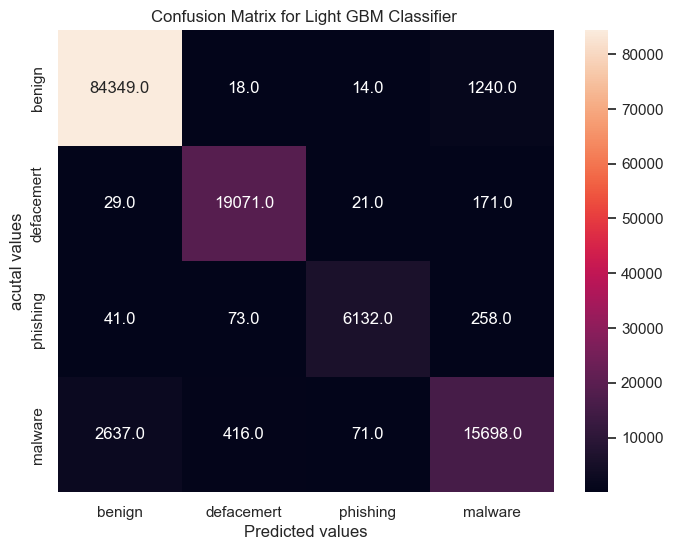

In [43]:
cm = confusion_matrix(y_test, y_pred_rf)
cm_df=pd.DataFrame(cm,index=['benign','defacemert','phishing','malware'],columns=['benign','defacemert','phishing','malware'])
plt.figure(figsize=(8,6))
sns.heatmap(cm_df,annot=True,fmt='.1f')
plt.title('Confusion Matrix for Light GBM Classifier ')
plt.xlabel('Predicted values')
plt.ylabel('acutal values')
plt.show()

<Axes: >

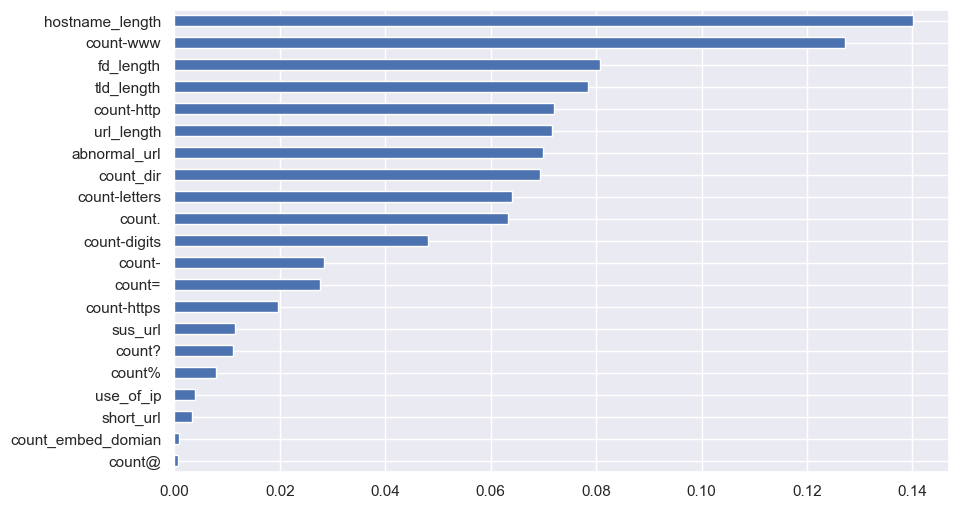

In [44]:
feat_importances= pd.Series(rf.feature_importances_,index=x.columns)
feat_importances.sort_values().plot(kind='barh',figsize=(10,6))

3-XGboost

In [45]:
xgb_c = xgb.XGBClassifier(n_estimators= 100)
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()


y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)



xgb_c.fit(x_train,y_train)
y_pred_x = xgb_c.predict(x_test)
print(classification_report(y_test,y_pred_x,target_names=['benign', 'defacement','phishing','malware']))
score = accuracy_score(y_test, y_pred_x)

print("accuracy:   %0.3f" % score)


              precision    recall  f1-score   support

      benign       0.97      0.99      0.98     85621
  defacement       0.95      0.98      0.97     19292
    phishing       0.97      0.90      0.93      6504
     malware       0.90      0.81      0.85     18822

    accuracy                           0.96    130239
   macro avg       0.95      0.92      0.93    130239
weighted avg       0.96      0.96      0.96    130239

accuracy:   0.956


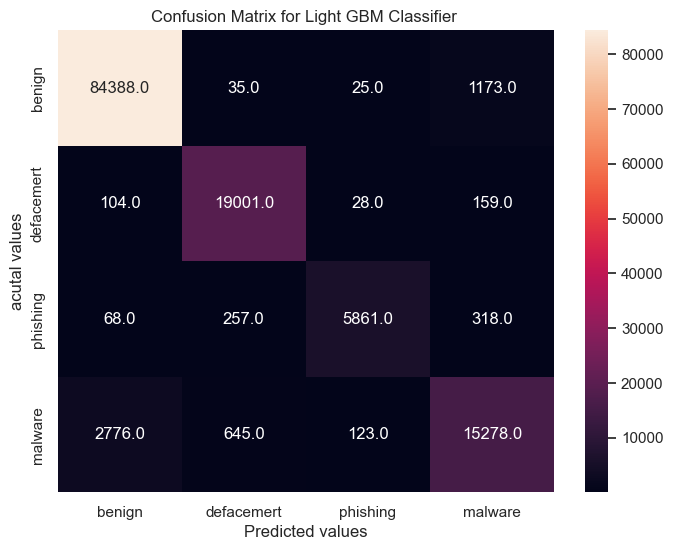

In [46]:
cm = confusion_matrix(y_test, y_pred_x)
cm_df=pd.DataFrame(cm,index=['benign','defacemert','phishing','malware'],columns=['benign','defacemert','phishing','malware'])
plt.figure(figsize=(8,6))
sns.heatmap(cm_df,annot=True,fmt='.1f')
plt.title('Confusion Matrix for Light GBM Classifier ')
plt.xlabel('Predicted values')
plt.ylabel('acutal values')
plt.show()

<Axes: >

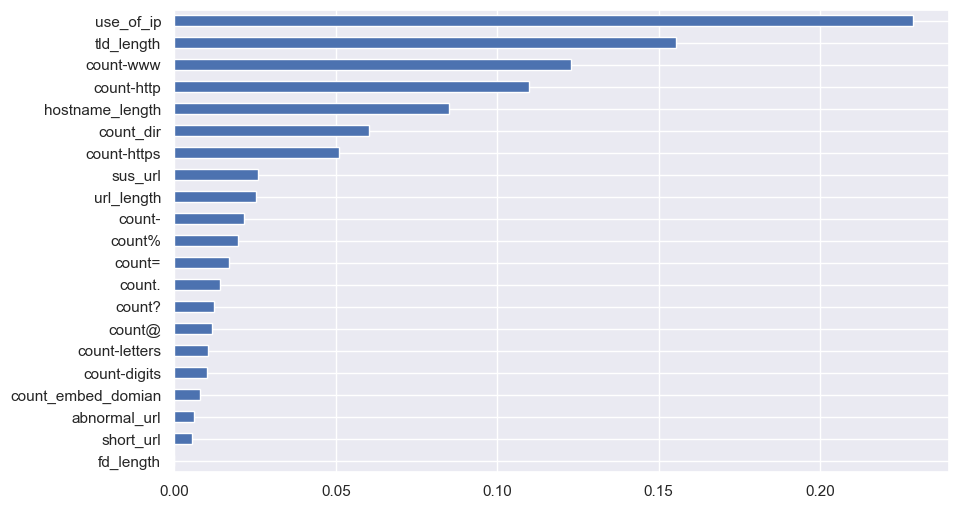

In [47]:
feat_importances= pd.Series(xgb_c.feature_importances_,index=x.columns)
feat_importances.sort_values().plot(kind='barh',figsize=(10,6))

In [48]:
def main(url):
    status = []
    status.append(having_ip_address(url))
    status.append(abnormal_url(url))
    status.append(count_dot(url))
    status.append(count_www(url))
    status.append(count_atrate(url))
    status.append(no_of_dir(url))
    status.append(no_of_embed(url))
    status.append(shortening_service(url))
    status.append(count_https(url))
    status.append(count_http(url))
    status.append(count_per(url))
    status.append(count_ques(url))
    status.append(count_hyphen(url))
    status.append(count_equal(url))
    status.append(url_length(url))
    status.append(hostname_length(url))
    status.append(suspicious_words(url))
    status.append(digit_count(url))
    status.append(letter_count(url))
    status.append(fd_length(url))

    tld = get_tld(url, fail_silently=True)
    status.append(tld_length(tld))

    return status


In [49]:
def get_prediction_from_url(test_url):
    features_test = main(test_url)
    features_test = np.array(features_test).reshape((1, -1))
    pred = lgb.predict(features_test)

    if pred[0] == "benign":
        res = "SAFE"
    elif pred[0] == "defacement":
        res = "DEFACEMENT"
    elif pred[0] == "phishing":
        res = "PHISHING"
    elif pred[0] == "malware":
        res = "MALWARE"
    else:
        res = "UNKNOWN"
    return res



In [50]:
urls = ['titanumcorporate.co.za', 'en.wikipedia.org/wiki/North_Dacota']
for url in urls:
    print(url, "==>", get_prediction_from_url(url))
    print()

titanumcorporate.co.za ==> PHISHING

en.wikipedia.org/wiki/North_Dacota ==> PHISHING

